In [1]:
import json
import time
import os
import random
from web3.logs import STRICT, IGNORE, DISCARD, WARN
import hexbytes
import pandas as pd
import matplotlib.pyplot as plt
from decimal import Decimal
from hexbytes import HexBytes
from pathlib import Path
import plotly.graph_objects as go
import requests
from requests.exceptions import HTTPError
from datetime import datetime, timezone
from web3 import Web3
from collections import defaultdict
from web3.exceptions import TransactionNotFound, BlockNotFound
from concurrent.futures import ThreadPoolExecutor, as_completed
import concurrent.futures
import sys
import threading
from functools import wraps

# === CONFIGURATION ===
# opensee.io
INFURA_URL = "https://mainnet.infura.io/v3/3921fc62a7ce4cda98926f47409b3d19"
ETHERSCAN_API_KEY = "F7K9BTHSSB9EQT9WEGHMG3VFJ54KA8RM1K"
# hearthquake
ETHERSCAN_API_KEY = "d28e1ba493794e6aadf097e4964279fb"
INFURA_URL = "https://mainnet.infura.io/v3/d28e1ba493794e6aadf097e4964279fb"
CONTRACT_ADDRESS = POOL_ADDRESS = "0xCBCdF9626bC03E24f779434178A73a0B4bad62eD"
ABI_FILE = "WETH_WBTC_pool.json"  # Load your contract ABI file
BLOCKS_FILE = "blocks_data.json"
TRANSACTIONS_FILE = "transactions.json"
METADATA_FILE = "processed_blocks.json"
BATCH_SIZE = 1000  # Number of transactions to process before writing to disk

# === CONNECT TO ETHEREUM NODE ===
# w3 = Web3(Web3.HTTPProvider(INFURA_URL))
w3 = Web3(
    Web3.HTTPProvider(INFURA_URL)
    #Web3.HTTPProvider("http://127.0.0.1:8545")
)
assert w3.is_connected(), "Web3 provider connection failed"

In [2]:
w3.eth.get_block('latest').number

23363979

In [3]:
# --------------------
# Helper Function: Get ABI from Etherscan or Disk
# --------------------

def get_abi(contract_address: str, api_key: str) -> list:
    """
    Retrieves the ABI for a given contract address.
    Checks if the ABI is available in the local 'ABI' folder.
    If not, it fetches the ABI from Etherscan using the provided API key,
    then saves it to disk for future use.
    
    Parameters:
        contract_address (str): The contract address (checksum not required here).
        api_key (str): Your Etherscan API key.
        
    Returns:
        list: The ABI loaded as a Python list.
    """
    # Ensure the ABI folder exists.
    abi_folder = "ABI"
    if not os.path.exists(abi_folder):
        os.makedirs(abi_folder)
    
    # Save ABI with filename based on contract address.
    filename = os.path.join(abi_folder, f"{contract_address}.json")
    
    # If file exists, load and return the ABI.
    if os.path.exists(filename):
        with open(filename, "r") as file:
            abi = json.load(file)
    else:
        # Construct the Etherscan API URL.
        url = f"https://api.etherscan.io/api?module=contract&action=getabi&address={contract_address}&apikey={api_key}"
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            if data["status"] == "1":
                # Parse the ABI and save it for later use.
                abi = json.loads(data["result"])
                with open(filename, "w") as file:
                    json.dump(abi, file)
            else:
                raise Exception(f"Error fetching ABI for contract {contract_address}: {data['result']}")
        else:
            raise Exception("Error connecting to the Etherscan API. Status code: " + str(response.status_code))
    return abi

# -----------------------
# Helper: Convert event to dict
# -----------------------
def event_to_dict(event):
    d = dict(event)
    if "args" in d:
        d["args"] = dict(d["args"])
    if "transactionHash" in d:
        d["transactionHash"] = d["transactionHash"].hex()
    if "blockHash" in d:
        d["blockHash"] = d["blockHash"].hex()
    return d

# -----------------------
# Metadata Computation from Events File
# -----------------------
def load_metadata_from_events():
    """
    Load metadata directly from EVENTS_FILE.
    Returns a dict with keys as chunk keys (e.g. "0-9999") and values as dicts of event type counts.
    """
    metadata = {}
    try:
        with open(EVENTS_FILE, "r") as f:
            for line in f:
                if line.strip():
                    try:
                        event = json.loads(line)
                        block_number = int(event.get("blockNumber", 0))
                        event_type = event.get("event", "Unknown")
                        chunk_start = (block_number // CHUNK_SIZE) * CHUNK_SIZE
                        chunk_end = chunk_start + CHUNK_SIZE - 1
                        chunk_key = f"{chunk_start}-{chunk_end}"
                        if chunk_key not in metadata:
                            metadata[chunk_key] = {}
                        metadata[chunk_key][event_type] = (
                            metadata[chunk_key].get(event_type, 0) + 1
                        )
                    except Exception as e:
                        print(f"Error processing a line in events file: {e}")
                        continue
    except FileNotFoundError:
        pass
    return metadata


def get_contract_creation_block_etherscan(contract_address: str, etherscan_api_key: str) -> int:
    """
    Retrieves the contract creation block from Etherscan.
    Returns the block number as an integer.
    """
    url = (f"https://api.etherscan.io/api?module=contract&action=getcontractcreation"
           f"&contractaddresses={contract_address}&apikey={etherscan_api_key}")
    response = requests.get(url)
    data = response.json()

    if data.get("status") == "1":
        results = data.get("result", [])
        if results and len(results) > 0:
            return int(results[0]["blockNumber"])
        else:
            raise Exception("No contract creation data found.")
    else:
        raise Exception("Error fetching creation block: " + data.get("result", "Unknown error"))


# Used to find at which block 1 contract has been deployed
# Might be useful later, put it in JSON in the end
def get_contract_creation_block_custom(start_block=0, end_block=100000):

    def get_contract_deployments(start_block, end_block, max_workers=8):
        deployments = []

        def process_block(block_number):
            block = w3.eth.get_block(block_number, full_transactions=True)
            block_deployments = []
            for tx in block.transactions:
                if tx.to is None:
                    try:
                        receipt = w3.eth.get_transaction_receipt(tx.hash)
                        contract_address = receipt.contractAddress
                        if contract_address:
                            block_deployments.append(
                                {
                                    "block_number": block_number,
                                    "contract_address": contract_address,
                                }
                            )
                    except:
                        print(tx.hash)
            return block_deployments

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            future_to_block = {
                executor.submit(process_block, bn): bn
                for bn in range(start_block, end_block + 1)
            }
            for future in as_completed(future_to_block):
                block_deployments = future.result()
                deployments.extend(block_deployments)

        return deployments

    deployments = get_contract_deployments(start_block, end_block)

    # Save the results to a JSON file
    with open("contract_deployments.json", "w") as f:
        json.dump(deployments, f, indent=4)


# -- Step 2: Reconstruct an Event’s Signature --
def get_event_signature(event_name: str, abi: list) -> str:
    """
    Given an event name and an ABI, find the event definition and reconstruct its signature.
    For example, for event Transfer(address,address,uint256) this returns its keccak256 hash.
    """
    from eth_utils import keccak, encode_hex

    for item in abi:
        if item.get("type") == "event" and item.get("name") == event_name:
            # Build the signature string: "Transfer(address,address,uint256)"
            types = ",".join([inp["type"] for inp in item.get("inputs", [])])
            signature = f"{event_name}({types})"
            return encode_hex(keccak(text=signature))
    raise ValueError(f"Event {event_name} not found in ABI.")


def block_to_utc(block_number):
    """
    Convert a block number into its UTC timestamp.

    Parameters:
        w3 (Web3): A Web3 instance
        block_number (int): The block number

    Returns:
        datetime: The block timestamp in UTC
    """
    block = w3.eth.get_block(block_number)
    timestamp = block["timestamp"]
    return datetime.fromtimestamp(timestamp, tz=timezone.utc).isoformat()


def read_and_sort_jsonl(file_path):
    """
    Reads a JSONL file, each line being a JSON object with a field `blockNumber`,
    and returns a list of those objects sorted by blockNumber (ascending).
    """
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError as e:
                # Handle bad JSON if needed, e.g., log or skip
                print(f"Skipping bad JSON line: {e}")
                continue
            # Optionally, you could check that 'blockNumber' exists, is int, etc.
            if "blockNumber" not in obj:
                print(f"Skipping line with no blockNumber: {obj}")
                continue
            data.append(obj)
    # Now sort by blockNumber ascending
    # If blockNumber in file is already int, fine; else convert
    sorted_data = sorted(data, key=lambda o: int(o["blockNumber"]))
    return sorted_data


# token_address = w3.to_checksum_address("0x86c8bF8532AA2601151c9DbbF4e4C4804e042571")
# token_abi = get_abi(token_address, ETHERSCAN_API_KEY)
# token_contract = w3.eth.contract(address=token_address, abi=token_abi)

token_address = w3.to_checksum_address("0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2")
token_abi = get_abi(token_address, ETHERSCAN_API_KEY)
token_contract = w3.eth.contract(address=token_address, abi=token_abi)

In [5]:
### We focus on the Factory contract of uniswap v1 "0xc0a47dFe034B400B47bDaD5FecDa2621de6c4d95"
# We need the ProviderNode to be initialized already
# Why debug_traceTransaction Is the Best Option
# It replays the transaction within the exact historical state using your archive node and returns a detailed call graph, including internal calls and value flows—not just high-level transfers. You can choose tracers like callTracer (which outputs call frames and nested structure) for highest clarity and insight.
# Alternatives like event logs or transaction receipts won't capture internal calls, since those are not emitted as events. You need a trace API to follow what's happening inside smart contract execution.
uniswap_v1_factory_address = w3.to_checksum_address("0xc0a47dFe034B400B47bDaD5FecDa2621de6c4d95")
uniswap_v1_factory_abi = get_abi(uniswap_v1_factory_address, ETHERSCAN_API_KEY)
uniswap_v1_factory_contract = w3.eth.contract(
    address=uniswap_v1_factory_address, abi=uniswap_v1_factory_abi
)

def trace_internal_transactions(tx_hash: str, tracer: str = "callTracer") -> dict:
    """
    Performs debug_traceTransaction with specified tracer (default: callTracer).
    Returns the full trace result as a Python dict.
    """
    trace = w3.provider.make_request(
        "debug_traceTransaction", [tx_hash, {"tracer": tracer}]
    )
    return trace.get("result", {})


def extract_internal_transfers_from_trace(trace: dict) -> list:
    """
    Recursively traverses the 'calls' in the trace to gather internal transfers.
    Returns list of dicts with from, to, value, gasUsed, etc.
    """
    transfers = []

    def recurse(call):
        # Internal transfer if value is non-zero
        value = int(call.get("value", "0x0"), 16)
        if value > 0:
            transfers.append(
                {
                    "from": call.get("from"),
                    "to": call.get("to"),
                    "value": value,
                    "gas": int(call.get("gas", "0x0"), 16),
                    "gasUsed": int(call.get("gasUsed", "0x0"), 16),
                    "type": call.get("type"),
                    "error": call.get("error"),
                }
            )
        for sub in call.get("calls", []) or []:
            recurse(sub)

    recurse(trace)
    return transfers


def get_internal_transactions_for_contract(
    contract_address: str, from_block: int, to_block: int
):
    """Scan blocks, identify txs to/from contract, and trace internal calls."""
    results = []
    for block_num in range(from_block, to_block + 1):
        block = w3.eth.get_block(block_num, full_transactions=True)
        for tx in block.transactions:
            if (
                 tx["to"]
                 and tx["to"] == uniswap_v1_factory_address
                 or tx["from"] == uniswap_v1_factory_address
            ):

                function, params = uniswap_v1_factory_contract.decode_function_input(
                    tx["input"]
                )
                if function.fn_name == 'createExchange':
                    #print(tx)
                    # print('Called function:', function.fn_name)
                    #print('With arguments:', params)
                    uni_created_token = params['token']
                    univ1_token_address = w3.to_checksum_address(uni_created_token)
                    univ1_factory_abi = get_abi(univ1_token_address, ETHERSCAN_API_KEY)
                    univ1_factory_contract = w3.eth.contract(
                        address=univ1_token_address, abi=univ1_factory_abi
                    )
                    token_name =  None
                    token_symbol = None 
                    try:
                        token_name = univ1_factory_contract.functions.name().call()
                        token_symbol = univ1_factory_contract.functions.symbol().call()
                        print(f"Token Name: {token_name}")
                        print(f"Token Symbol: {token_symbol}")
                    except:
                        print(f"Contract is a proxy {uni_created_token}")

                    token_created_exchange_address = uniswap_v1_factory_contract.functions.getExchange(
                        uni_created_token
                    ).call()
                    print(f"Token {token_name} UniExchange_address: {token_created_exchange_address}")
                    a = w3.to_checksum_address(token_created_exchange_address)
                    b = get_abi(a, ETHERSCAN_API_KEY)
                    c = w3.eth.contract(
                        address=a, abi=b
                    )
                    try:
                        #print(f"{c.functions.name.call()}")
                        #print(f"{c.functions.symbol.call()}")
                        print(f"Token Address: {c.functions.tokenAddress.call()}")
                        #print(
                        #    f"Is this the same ? {c.functions.tokenAddress.call() == uni_created_token}"
                        #)
                    except:
                        print(f"proxy: {c}")
            #     tx_hash = tx.hash.hex()
            #     trace = trace_internal_transactions(tx_hash)
            #     transfers = extract_internal_transfers_from_trace(trace)
            #     results.append(
            #         {
            #             "tx_hash": tx_hash,
            #             "block": block_num,
            #             "internal_transfers": transfers,
            #         }
            #     )
    return results

internal_txs = get_internal_transactions_for_contract(
    uniswap_v1_factory_contract, 6627900, w3.eth.get_block("latest").number
    #uniswap_v1_factory_contract, 6500000, w3.eth.get_block("latest").number
)
for entry in internal_txs:
    print(entry["tx_hash"], entry["internal_transfers"])

Token Name: b'Maker\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Token Symbol: b'MKR\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Token b'Maker\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00' UniExchange_address: 0x2C4Bd064b998838076fa341A83d007FC2FA50957
Token Address: 0x9f8F72aA9304c8B593d555F12eF6589cC3A579A2
Token Name: OMGToken
Token Symbol: OMG
Token OMGToken UniExchange_address: 0xDdee242662323a3cff3F9AA139fFA496aC3C73B0
Token Address: 0xd26114cd6EE289AccF82350c8d8487fedB8A0C07
Token Name: 0x Protocol Token
Token Symbol: ZRX
Token 0x Protocol Token UniExchange_address: 0xaE76c84C9262Cdb9abc0C2c8888e62Db8E22A0bF
Token Address: 0xE41d2489571d322189246DaFA5ebDe1F4699F498
Token Name: BNB
Token Symbol: BNB
Token BNB UniExchange_address: 0x255e60c9d597dCAA66006A904eD36424F7B26286
Token Addre

KeyboardInterrupt: 

In [ ]:
# Once having the uniswap exchange for 1 token, we need to analyze the liquidity movement, swap, volume and fees
# BNB: 0x255e60c9d597dCAA66006A904eD36424F7B26286
uniswap_v1_BNB_exchange_address = w3.to_checksum_address(
    "0x255e60c9d597dCAA66006A904eD36424F7B26286"
    # "0x2157A7894439191E520825FE9399AB8655E0F708"
)
uniswap_v1_BNB_exchange_abi = get_abi(uniswap_v1_BNB_exchange_address, ETHERSCAN_API_KEY)
uniswap_v1_BNB_exchange_contract = w3.eth.contract(
    address=uniswap_v1_BNB_exchange_address, abi=uniswap_v1_BNB_exchange_abi
)
# from_block = 6827900
from_block = 6800000
step = 100000

def extract_liquidity_data(logs, provider_address, start_block, end_block):
    """Extract and format liquidity data for a specific provider."""
    liquidity_data = defaultdict(int)

    for log in logs:
        log = parse_event(log)
        if log["blockNumber"] < start_block or log["blockNumber"] > end_block:
            continue

        if log["args"]["provider"].lower() == provider_address.lower():
            if log["event"] == "AddLiquidity":
                liquidity_data[log["blockNumber"]] += (
                    log["args"]["eth_amount"] + log["args"]["token_amount"]
                )
            elif log["event"] == "RemoveLiquidity":
                liquidity_data[log["blockNumber"]] -= (
                    log["args"]["eth_amount"] + log["args"]["token_amount"]
                )
            elif log["event"] == "Transfer":
                if log["args"]["_from"].lower() == provider_address.lower():
                    liquidity_data[log["blockNumber"]] -= log["args"]["_value"]
                elif log["args"]["_to"].lower() == provider_address.lower():
                    liquidity_data[log["blockNumber"]] += log["args"]["_value"]

    return dict(liquidity_data)


for i in range(from_block, w3.eth.get_block('latest').number, step):
    # for event in uniswap_v1_BNB_exchange_contract.events:
    # event is now the class/type of the event, e.g. 'Swap'
    # event_fn = getattr(uniswap_v1_BNB_exchange_contract.events, event.event_name)
    # result = event_fn().get_logs(from_block=i, to_block=i + step)
    r = uniswap_v1_BNB_exchange_contract.events.AddLiquidity.get_logs(
        from_block=i, to_block=i + step
    )
    # r == s ? True
    s = uniswap_v1_BNB_exchange_contract.events.AddLiquidity().get_logs(
        from_block=i, to_block=i + step
    )
    t = uniswap_v1_BNB_exchange_contract.events.Transfer.get_logs(
        from_block=i, to_block=i + step
    )
    u = uniswap_v1_BNB_exchange_contract.events.Transfer().get_logs(
        from_block=i, to_block=i + step
    )
    v = uniswap_v1_BNB_exchange_contract.events.AddLiquidity.create_filter(
        from_block=i, to_block=i + step
    )
    w = uniswap_v1_BNB_exchange_contract.events.AddLiquidity().create_filter(
        from_block=i, to_block=i + step
    )
    # result = uniswap_v1_BNB_exchange_contract.events..get_logs(
    #    from_block=i, to_block=i + step
    # )
    for event in v.get_new_entries():
        print("Event:", event["event"])
        print("Args:", event["args"])
        print("Transaction hash:", event["transactionHash"].hex())
        print("Block number:", event["blockNumber"])
        print("---")
    for event in w.get_new_entries():
        print("Event:", event["event"])
        print("Args:", event["args"])
        print("Transaction hash:", event["transactionHash"].hex())
        print("Block number:", event["blockNumber"])
        print("---")
    print(f"{(r, s, t, u, v, w)}")
    print(f"{i} - {i+step}")

    break


([AttributeDict({'args': AttributeDict({'provider': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6', 'eth_amount': 1000000000000000000, 'token_amount': 20200000000000000000}), 'event': 'AddLiquidity', 'logIndex': 40, 'transactionIndex': 75, 'transactionHash': HexBytes('0x1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6'), 'address': '0x255e60c9d597dCAA66006A904eD36424F7B26286', 'blockHash': HexBytes('0x96ba61eb50602507ce0bcfc98ec4e9b363d624a6efb1140916be38906fcdad66'), 'blockNumber': 6845141}), AttributeDict({'args': AttributeDict({'provider': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6', 'eth_amount': 2500000000000000000, 'token_amount': 50500000000000000001}), 'event': 'AddLiquidity', 'logIndex': 15, 'transactionIndex': 23, 'transactionHash': HexBytes('0x883fa20677e652038a11297b3cc33b3ff6b694fb6fe7cbc1cbbec0117669387b'), 'address': '0x255e60c9d597dCAA66006A904eD36424F7B26286', 'blockHash': HexBytes('0xa9c31a421bb4ac35b46ae2b50c65a48b4c493cde42b74f2c8e9de5f3bfcd7057'), 'b

In [5]:
# Super important code, for 1 transaction, we get all the Transfer event and we analyze which token has been exchanged
# we also get the Gas + ETH send. If we analyze all the transaction from 1 exchange, we can probably deduct all the liquidity
# token issued by the pair_exchange
uniswap_v1_BNB_exchange_address = w3.to_checksum_address(
    "0x255e60c9d597dCAA66006A904eD36424F7B26286"
)
uniswap_v1_BNB_exchange_abi = get_abi(
    uniswap_v1_BNB_exchange_address, ETHERSCAN_API_KEY
)
uniswap_v1_BNB_exchange_contract = w3.eth.contract(
    address=uniswap_v1_BNB_exchange_address, abi=uniswap_v1_BNB_exchange_abi
)
transaction = w3.eth.get_transaction(
    "1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6"
)
d_transaction = event_to_dict(transaction)
tx_eth_value = w3.from_wei(d_transaction["value"], "ether")
decoded = uniswap_v1_BNB_exchange_contract.events.Transfer().process_receipt(
    w3.eth.get_transaction_receipt(transaction.hash),
    DISCARD,
)
for ev in decoded:
    d_ev = event_to_dict(ev)
    d_from = d_ev['args']['_from']
    d_to = d_ev['args']['_to']
    d_value = w3.from_wei(d_ev["args"]["_value"], "ether")
    d_address = d_ev['address']
    d_block = d_ev['blockNumber']
    d_tx_hash = d_ev["transactionHash"]
    token_address = w3.to_checksum_address(d_address)
    token_abi = get_abi(token_address, ETHERSCAN_API_KEY)
    token_contract = w3.eth.contract(address=token_address, abi=token_abi)
    symbol = token_contract.functions.symbol().call()
    decimals = token_contract.functions.decimals().call()
    print(
        f"Block number {d_block}, {tx_eth_value} ETH was used, {d_to} received {d_value} of {symbol} from {d_from} (tx_hash is {d_tx_hash})"
    )

def analyze_transaction_transfers(tx_hash, pair_exchange_contract, etherscan_api_key):
    result = []
    transaction = w3.eth.get_transaction(
        tx_hash
    )
    d_transaction = event_to_dict(transaction)
    tx_eth_value = w3.from_wei(d_transaction["value"], "ether")
    decoded = pair_exchange_contract.events.Transfer().process_receipt(
        w3.eth.get_transaction_receipt(transaction.hash),
        DISCARD,
    )
    for ev in decoded:
        _ = {}
        d_ev = event_to_dict(ev)
        d_from = d_ev["args"]["_from"]
        d_to = d_ev["args"]["_to"]
        d_value = w3.from_wei(d_ev["args"]["_value"], "ether")
        d_address = d_ev["address"]
        d_block = d_ev["blockNumber"]
        d_tx_hash = d_ev["transactionHash"]
        token_address = w3.to_checksum_address(d_address)
        token_abi = get_abi(token_address, etherscan_api_key)
        token_contract = w3.eth.contract(address=token_address, abi=token_abi)
        symbol = token_contract.functions.symbol().call()
        decimals = token_contract.functions.decimals().call()
        _["d_block"] = d_block
        _["d_from"] = d_from
        _["d_to"] = d_to
        _["d_value"] = d_value
        _["d_address"] = d_address
        _["d_tx_hash"] = d_tx_hash
        _["symbol"] = symbol
        _["decimals"] = decimals
        print(
            f"Block number {d_block}, {tx_eth_value} ETH was used, {d_to} received {d_value} of {symbol} from {d_from} (tx_hash is {d_tx_hash})"
        )
        result.append(_)
    return result

Block number 6845141, 1 ETH was used, 0x255e60c9d597dCAA66006A904eD36424F7B26286 received 20.2 of BNB from 0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6 (tx_hash is 1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6)
Block number 6845141, 1 ETH was used, 0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6 received 1 of b'UNI-V1\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00' from 0x0000000000000000000000000000000000000000 (tx_hash is 1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6)


In [6]:
sorted_transactions = read_and_sort_jsonl('related_txs.jsonl')
uniswap_v1_BNB_exchange_address = w3.to_checksum_address(
    "0x255e60c9d597dCAA66006A904eD36424F7B26286"
)
uniswap_v1_BNB_exchange_abi = get_abi(uniswap_v1_BNB_exchange_address, ETHERSCAN_API_KEY)
uniswap_v1_BNB_exchange_contract = w3.eth.contract(
    address=uniswap_v1_BNB_exchange_address, abi=uniswap_v1_BNB_exchange_abi
)
result = []
for tx in sorted_transactions:
    # print(tx)
    _ = analyze_transaction_transfers(
        tx['txHash'],
        uniswap_v1_BNB_exchange_contract,
        etherscan_api_key=ETHERSCAN_API_KEY,
    )
    result.append(_)

Block number 6845141, 1 ETH was used, 0x255e60c9d597dCAA66006A904eD36424F7B26286 received 20.2 of BNB from 0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6 (tx_hash is 1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6)
Block number 6845141, 1 ETH was used, 0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6 received 1 of b'UNI-V1\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00' from 0x0000000000000000000000000000000000000000 (tx_hash is 1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6)
Block number 6845156, 2.5 ETH was used, 0x255e60c9d597dCAA66006A904eD36424F7B26286 received 50.500000000000000001 of BNB from 0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6 (tx_hash is 883fa20677e652038a11297b3cc33b3ff6b694fb6fe7cbc1cbbec0117669387b)
Block number 6845156, 2.5 ETH was used, 0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6 received 2.5 of b'UNI-V1\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [7]:
result

[[{'d_block': 6845141,
   'd_from': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6',
   'd_to': '0x255e60c9d597dCAA66006A904eD36424F7B26286',
   'd_value': Decimal('20.2'),
   'd_address': '0xB8c77482e45F1F44dE1745F52C74426C631bDD52',
   'd_tx_hash': '1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6',
   'symbol': 'BNB',
   'decimals': 18},
  {'d_block': 6845141,
   'd_from': '0x0000000000000000000000000000000000000000',
   'd_to': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6',
   'd_value': Decimal('1'),
   'd_address': '0x255e60c9d597dCAA66006A904eD36424F7B26286',
   'd_tx_hash': '1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6',
   'symbol': b'UNI-V1\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00',
   'decimals': 18}],
 [{'d_block': 6845156,
   'd_from': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6',
   'd_to': '0x255e60c9d597dCAA66006A904eD36424F7B26286',
   'd_value': Decimal('50.50000000000000000

In [ ]:
result

def process_liquidity_events_full(
    events, token_symbol: str = "TOKEN", epsilon: Decimal = Decimal("1e-8")
):
    """
    Process explicit AddLiquidity / RemoveLiquidity events.

    Args:
        events: list of dicts, each with keys:
            - 'block' (int)
            - 'type' (str): either 'add' or 'remove'
            - 'provider' (str): address
            - 'eth_amount' (Decimal)
            - 'token_amount' (Decimal)
        token_symbol: label for the token asset
        epsilon: minimal threshold under which we consider an address has removed essentially all its liquidity

    Returns:
        df: DataFrame indexed by block, with forward‐filled cumulative data:
            * cum_eth_liq: cumulative ETH liquidity in pool
            * cum_token_liq: cumulative token liquidity in pool
            * cum_total_liq: sum of both (token + ETH) (pure sum, no price)
            * distinct_providers: number of providers with *net* contribution > epsilon
            * provider_liquidity: nested dict: for each provider, their ETH+token net contribution over time (optional)
    """

    # Make a DataFrame of events
    df_events = pd.DataFrame(events)
    # Ensure correct types
    df_events["block"] = df_events["block"].astype(int)
    df_events["eth_amount"] = df_events["eth_amount"].astype(object)  # keep as Decimal
    df_events["token_amount"] = df_events["token_amount"].astype(object)
    df_events["provider"] = df_events["provider"].str.lower()

    # Sort by block
    df_events = df_events.sort_values("block").reset_index(drop=True)

    # Get the full range of blocks from min to max
    block_min = df_events["block"].min()
    block_max = df_events["block"].max()

    # Prepare lists to accumulate
    blocks = list(range(block_min, block_max + 1))
    cum_eth = []
    cum_token = []
    cum_total = []
    distinct_providers_counts = []

    # Track per‐provider net contribution (eth + token separately or combined; here combined for simplification)
    provider_eth_net = defaultdict(lambda: Decimal("0"))
    provider_token_net = defaultdict(lambda: Decimal("0"))

    current_eth = Decimal("0")
    current_token = Decimal("0")

    # We'll iterate through blocks; for each block, apply events, then record state
    events_by_block = df_events.groupby("block")

    for blk in blocks:
        if blk in events_by_block.groups:
            evs = events_by_block.get_group(blk)
            for _, ev in evs.iterrows():
                prov = ev["provider"]
                if ev["type"] == "add":
                    current_eth += ev["eth_amount"]
                    current_token += ev["token_amount"]
                    provider_eth_net[prov] += ev["eth_amount"]
                    provider_token_net[prov] += ev["token_amount"]
                elif ev["type"] == "remove":
                    current_eth -= ev["eth_amount"]
                    current_token -= ev["token_amount"]
                    provider_eth_net[prov] -= ev["eth_amount"]
                    provider_token_net[prov] -= ev["token_amount"]
                else:
                    # skip or error
                    continue

        # after updating for block, compute totals
        cum_eth.append(current_eth)
        cum_token.append(current_token)
        cum_total.append(current_eth + current_token)

        # compute how many providers have net > epsilon
        count = sum(
            1
            for prov in provider_eth_net
            if (provider_eth_net[prov] + provider_token_net[prov]) > epsilon
        )
        distinct_providers_counts.append(count)

    # Build resulting DataFrame
    df = pd.DataFrame(
        {
            "block": blocks,
            "cum_eth_liq": cum_eth,
            "cum_token_liq": cum_token,
            "cum_total_liq": cum_total,
            "distinct_providers": distinct_providers_counts,
        }
    )

    return df, provider_eth_net, provider_token_net


def plot_liquidity_and_providers(
    df,
    provider_eth_net: dict,
    provider_token_net: dict,
    token_symbol: str = "TOKEN",
    top_n_providers: int = 5,
):
    """
    Plot multiple graphs:
      1) Liquidity curves (ETH, token, total)
      2) Liquidity contributions of top providers + total distinct providers count
    """

    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # 1) Liquidity over time
    axs[0].plot(df["block"], df["cum_eth_liq"], label="ETH Liquidity", color="blue")
    axs[0].plot(
        df["block"],
        df["cum_token_liq"],
        label=f"{token_symbol} Liquidity",
        color="orange",
    )
    axs[0].plot(
        df["block"],
        df["cum_total_liq"],
        label="Total Liquidity (ETH + Token)",
        color="green",
    )
    axs[0].set_ylabel("Liquidity amount")
    axs[0].set_title("Liquidity evolution")
    axs[0].legend()
    axs[0].grid(True)

    # 2) Provider contributions & distinct count
    # Identify top providers by total (absolute) contribution (eth + token) in the latest state
    # Combine ETH + token net for ranking (simple sum); you might weight or normalize if needed
    combined_net = {
        p: provider_eth_net[p] + provider_token_net[p] for p in provider_eth_net
    }
    # Sort by absolute contribution
    top_providers = sorted(combined_net.items(), key=lambda x: abs(x[1]), reverse=True)[
        :top_n_providers
    ]
    top_providers = [p for p, _ in top_providers]

    # For each top provider, build their net contribution over blocks
    # We need to reconstruct a time series per provider
    # Let's rebuild by walking through blocks like above
    blocks = df["block"].tolist()

    # Initialize per provider series
    provider_series = {p: [] for p in top_providers}

    # We'll need to recompute per provider contribution per block again
    # Alternative: during process_liquidity_events_full we could have recorded time series per provider; here we just rebuild

    # Create a lookup of events by block for efficiency
    # You may want to cache or pass this in
    # We'll assume we have access to original events too; for demonstration, assume a global or closure

    # For demonstration, let's assume events list is accessible as `events_list`
    # Let's require passing events_list into this function; I'll update signature accordingly

    raise NotImplementedError(
        "You should pass events_list to allow per-provider time series build"
    )

    # Then:
    # axs[1].plot each provider's series with its own color
    # Also plot df['distinct_providers'] as a separate line
    # Add legend, etc.

    # Finally:
    # plt.tight_layout()
    # plt.show()


# Example of integrating both:

# Suppose you have events in below form:
# events = [
#   {'block': 100, 'type': 'add', 'provider': '0xabc...', 'eth_amount': Decimal(...), 'token_amount': Decimal(...)},
#   {'block': 120, 'type': 'remove', 'provider': '0xabc...', 'eth_amount': Decimal(...), 'token_amount': Decimal(...)},
#   ...
# ]

# Then:

# df, provider_eth_net, provider_token_net = process_liquidity_events_full(events, token_symbol='UNI-V1', epsilon=Decimal('1e-6'))
# plot_liquidity_and_providers(df, provider_eth_net, provider_token_net, token_symbol='UNI-V1', top_n_providers=5)

[[{'d_block': 6845141,
   'd_from': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6',
   'd_to': '0x255e60c9d597dCAA66006A904eD36424F7B26286',
   'd_value': Decimal('20.2'),
   'd_address': '0xB8c77482e45F1F44dE1745F52C74426C631bDD52',
   'd_tx_hash': '1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6',
   'symbol': 'BNB',
   'decimals': 18},
  {'d_block': 6845141,
   'd_from': '0x0000000000000000000000000000000000000000',
   'd_to': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6',
   'd_value': Decimal('1'),
   'd_address': '0x255e60c9d597dCAA66006A904eD36424F7B26286',
   'd_tx_hash': '1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6',
   'symbol': b'UNI-V1\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00',
   'decimals': 18}],
 [{'d_block': 6845156,
   'd_from': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6',
   'd_to': '0x255e60c9d597dCAA66006A904eD36424F7B26286',
   'd_value': Decimal('50.50000000000000000

In [ ]:
# Copy of the exploration block to trace function block by block
# Super interesting to get all the liquidity
# The problem is, we need the receipt of the transaction, and also its not straightforward to see
# the amount of liquidity directly from those call
# 

uniswap_v1_factory_address = w3.to_checksum_address(
    "0x255e60c9d597dCAA66006A904eD36424F7B26286"
    #"0x2157A7894439191E520825FE9399AB8655E0F708"
)
uniswap_v1_factory_abi = get_abi(uniswap_v1_factory_address, ETHERSCAN_API_KEY)
uniswap_v1_factory_contract = w3.eth.contract(
    address=uniswap_v1_factory_address, abi=uniswap_v1_factory_abi
)

def get_internal_transactions_for_contract(
    contract_address: str, from_block: int, to_block: int
):
    """Scan blocks, identify txs to/from contract, and trace internal calls."""
    results = []
    for block_num in range(from_block, to_block + 1):
        block = w3.eth.get_block(block_num, full_transactions=True)
        for tx in block.transactions:
            if (
                tx["to"]
                and (tx["to"] == uniswap_v1_factory_address
                or tx["from"] == uniswap_v1_factory_address)
            ):
                function, params = uniswap_v1_factory_contract.decode_function_input(
                    tx["input"]
                )
                if function.fn_name == "addLiquidity":
                    print(tx)
                    print('Called function:', function.fn_name)
                    print('With arguments:', params)
                    # print(f"Deadline: {block_to_utc(params['deadline'])}")
                    print(f"Deadline: {datetime.fromtimestamp(params['deadline'], tz=timezone.utc)}")
                    print(f"Value: {w3.from_wei(tx.value, 'ether')}")
                    try:
                        print(f"Receipt from transaction: {w3.eth.get_transaction_receipt(tx.hash)}")
                    except:
                        print(f"Can't find 0x{tx.hash.hex()}")
                    # tx.hash.hex()
    return results

# Interesting but I'm pruned
# trace = w3.provider.make_request("trace_transaction", [tx_hash])
# print(trace)
block_1 = 6845140
block_2 = 6850000
internal_txs = get_internal_transactions_for_contract(
    uniswap_v1_factory_contract,
    block_1,
    block_2
    #w3.eth.get_block("latest").number,
)

AttributeDict({'type': 0, 'chainId': 1, 'nonce': 2, 'gasPrice': 5000000000, 'gas': 165556, 'to': '0x255e60c9d597dCAA66006A904eD36424F7B26286', 'value': 1000000000000000000, 'input': HexBytes('0x422f104300000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011854d0f9cee40000000000000000000000000000000000000000000000000000000000005c0af767'), 'r': HexBytes('0x548fe1148970386fdfaa48d929aa23478303a8f7d17f5fc337e8de1f3b64d51f'), 's': HexBytes('0x44135f14d5ed009876e4121fc7e86d349c73332ebcab17787fa1cc3acf8b3899'), 'v': 37, 'hash': HexBytes('0x1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6'), 'blockHash': HexBytes('0x96ba61eb50602507ce0bcfc98ec4e9b363d624a6efb1140916be38906fcdad66'), 'blockNumber': 6845141, 'transactionIndex': 75, 'from': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6'})
Called function: addLiquidity
With arguments: {'min_liquidity': 0, 'max_tokens': 20200000000000000000, 'deadline': 1544222567}
Deadline: 20

In [ ]:
# Very old piece of code, just interesting for getting the signature of event
# Let's keep it in case of

# Example: get the Transfer event signature.
transfer_sig = get_event_signature("Transfer", token_abi)
add_liq_sig = get_event_signature("AddLiquidity", token_abi)
remove_liq_sig = get_event_signature("RemoveLiquidity", token_abi)
print("Transfer signature hash:", transfer_sig)

# -- Step 3: Determine Token Genesis Block and Set Starting Block --
# Assume you have a helper function get_contract_creation_block() that returns the creation block number.
try:
    genesis_block = get_contract_creation_block(token_address, ETHERSCAN_API_KEY)
    start_block = max(genesis_block - 1, 0)
except Exception as e:
    print("Error retrieving genesis block, defaulting to block 0:", e)
    start_block = 0

# -- Step 4: Fetch Transfer Events and Dump to a File (JSON Serializing) --
def get_transfer_events_paginated(token_contract, from_block: int, to_block: int, chunk_size: int = 5000, max_workers: int = 1) -> list:
    """
    Fetches Transfer events for a token_contract in the block range [from_block, to_block],
    paginating by chunk_size to avoid Infura's result limit. Uses moderate parallelization.

    Args:
        token_contract: A Web3 contract instance with a loaded ABI.
        from_block (int): The starting block number.
        to_block (int): The ending block number.
        chunk_size (int): How many blocks to query per chunk (default 5000).
        max_workers (int): Maximum number of parallel workers (default 4).

    Returns:
        List of events.
    """
    events_collected = []
    block_ranges = []
    
    # Divide the full range into chunks.
    for start_blk in range(from_block, to_block + 1, chunk_size):
        end_blk = min(start_blk + chunk_size - 1, to_block)
        block_ranges.append((start_blk, end_blk))
    
    def fetch_range(brange):
        print(f"Fetching for {brange}")
        start_blk, end_blk = brange
        attempts = 0
        max_retries = 5
        while attempts < max_retries:
            try:
                # Add delay to mitigate rate limits.
                time.sleep(random.uniform(1, 3))
                #events = token_contract.events.Transfer.get_logs(from_block=start_blk, to_block=end_blk)
                events = token_contract.events.AddLiquidity.get_logs(from_block=start_blk, to_block=end_blk)
                print(len(events))
                return events
            except Exception as e:
                if "429" in str(e):
                    sleep_time = random.uniform(1, 5)
                    print(f"429 error for blocks {start_blk}-{end_blk}: retrying after {sleep_time:.2f} seconds...")
                    time.sleep(sleep_time)
                    attempts += 1
                else:
                    print(f"Error fetching logs for blocks {start_blk}-{end_blk}: {e}")
                    return []
        return []  # Return empty list if all retries fail.
    
    # Use moderate parallelization.
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_range = {executor.submit(fetch_range, brange): brange for brange in block_ranges}
        for future in concurrent.futures.as_completed(future_to_range):
            events = future.result()
            events_collected.extend(events)
    
    return events_collected
    
# Custom function to convert a web3 event (and its custom types) to a plain dict.
def serialize_event(event):
    # Convert the AttributeDict to a normal dict.
    event_dict = dict(event)
    # Ensure all values are JSON serializable (convert any bytes, HexBytes etc. to a string)
    for key, value in event_dict.items():
        if hasattr(value, "hex"):
            event_dict[key] = value.hex()
    # Also convert inner "args" if present.
    if "args" in event_dict:
        args = dict(event_dict["args"])
        for k, v in args.items():
            if hasattr(v, "hex"):
                args[k] = v.hex()
        event_dict["args"] = args
    return event_dict

# Fetch logs from start_block to the current block (latest)
latest_block = w3.eth.block_number


event_list = get_transfer_events_paginated(token_contract, start_block, latest_block)
# Dump the result to a file (pretty-printing the JSON)
output_filename = f"transfer_events_{contract_address}.json"
with open(output_filename, "w") as f:
    import json
    json.dump(serialized_events, f, indent=4)

print(f"Dumped {len(serialized_events)} events to {output_filename}")


In [ ]:
# Find the amount of token depending on the contract at the very specific block_number
# but it use ETHERSCAN API (to go further: explorer the reconstruct from all the Transfer event but slow)
# Not super useful for the moment

def get_erc20_balance_at_block(contract, address, block_number):
    """
    Query ERC-20 balance of an address at a specific block.

    Parameters:
        contract: Web3 contract instance for the ERC-20 token
        address: string, account to check
        block_number: int, historical block

    Returns:
        int: token balance
    """
    balance = contract.functions.balanceOf(address).call(block_identifier=block_number)
    return balance


# Example usage:
uniswap_v1_BNB_exchange_address = w3.to_checksum_address(
    "0x255e60c9d597dCAA66006A904eD36424F7B26286"
    # "0x2157A7894439191E520825FE9399AB8655E0F708"
)
uniswap_v1_BNB_exchange_abi = get_abi(
    uniswap_v1_BNB_exchange_address, ETHERSCAN_API_KEY
)
uniswap_v1_BNB_exchange_contract = w3.eth.contract(
    address=uniswap_v1_BNB_exchange_address, abi=uniswap_v1_BNB_exchange_abi
)
user_address = "0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6"
block_number = 6845141

balance = get_erc20_balance_at_block(
    uniswap_v1_BNB_exchange_contract, user_address, block_number
)
print(f"Balance at block {block_number}: {balance / 1e18} tokens")

Balance at block 6845141: 1.0 tokens


In [ ]:
# This piece of code explore block 1 by 1 to find every transaction emitted or received from 1 address
# It's super slow but very deep investigation

def get_internal_transactions_with_trace(
    contract_address: str,
    from_block: int,
    to_block: int,
    max_workers: int = 16,
):
    """
    Fetch all transactions involving a contract and optionally trace internal calls.

    Parameters:
        w3: Web3 instance connected to a local archive node.
        contract_address: Ethereum contract address (string).
        from_block: Starting block number (int).
        to_block: Ending block number (int).
        max_workers: Number of threads for parallel fetching.

    Returns:
        List of dictionaries, each containing:
            - 'transaction': The transaction object.
            - 'internal_calls': List of internal calls (empty if trace not available).
    """
    results = []

    def process_block(block_number: int):
        """Fetch transactions in a block and trace internal calls if available."""
        block = w3.eth.get_block(block_number, full_transactions=True)
        block_results = []

        for tx in block.transactions:
            # Filter top-level transactions to/from the contract
            if tx["to"] == contract_address or tx["from"] == contract_address:
                tx_entry = {"transaction": tx, "internal_calls": []}

                # Try to fetch internal calls via trace_transaction
                try:
                    trace = w3.manager.request_blocking(
                        "trace_transaction", [tx["hash"].hex()]
                    )
                    tx_entry["internal_calls"] = trace
                except Exception as e:
                    # If trace API not enabled, just skip internal calls
                    tx_entry["internal_calls"] = []

                block_results.append(tx_entry)

        return block_results

    # Use ThreadPoolExecutor to fetch blocks in parallel
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(process_block, b): b
            for b in range(from_block, to_block + 1)
        }
        for future in as_completed(futures):
            results.extend(future.result())

    return results

block_1 = 6845140
block_2 = 6850000
contract_address = "0x255e60c9d597dCAA66006A904eD36424F7B26286"
txs_with_internal = get_internal_transactions_with_trace(contract_address, block_1, block_2)
for tx_entry in txs_with_internal:
    print(tx_entry)

[{'transaction': AttributeDict({'type': 0, 'chainId': 1, 'nonce': 2, 'gasPrice': 5000000000, 'gas': 165556, 'to': '0x255e60c9d597dCAA66006A904eD36424F7B26286', 'value': 1000000000000000000, 'input': HexBytes('0x422f104300000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011854d0f9cee40000000000000000000000000000000000000000000000000000000000005c0af767'), 'r': HexBytes('0x548fe1148970386fdfaa48d929aa23478303a8f7d17f5fc337e8de1f3b64d51f'), 's': HexBytes('0x44135f14d5ed009876e4121fc7e86d349c73332ebcab17787fa1cc3acf8b3899'), 'v': 37, 'hash': HexBytes('0x1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6'), 'blockHash': HexBytes('0x96ba61eb50602507ce0bcfc98ec4e9b363d624a6efb1140916be38906fcdad66'), 'blockNumber': 6845141, 'transactionIndex': 75, 'from': '0x3DE8C28084fd46F3c47D2bA16784a95E647f25B6'}), 'internal_calls': []}, {'transaction': AttributeDict({'type': 0, 'chainId': 1, 'nonce': 3, 'gasPrice': 10000000000, 'gas'

In [12]:
# === Contract scanner (uses web3.py documented API only) ===
# expects: `w3` (Web3 instance) already defined in your environment

#import json
#import time
#import random
#from pathlib import Path
#from typing import Any, Optional
#from web3 import Web3
#from web3.exceptions import TransactionNotFound, BlockNotFound

# Config (tweak to taste)
META_PATH = Path("scanned_meta.json")
RESULTS_PATH = Path("related_txs.jsonl")  # JSON-lines of discovered txs
TRACES_PATH = Path("tx_traces.jsonl")  # JSON-lines of traces (when available)
BASE_DELAY = 0.25  # base wait between RPC calls (s)
SLOW_EXTRA = 1.0  # extra delay when slow_mode=True (s)
JITTER = 0.25  # random jitter added to sleeps (s)
MAX_RETRIES = 5


def _append_jsonl(path: Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as fh:
        fh.write(json.dumps(obj, default=str) + "\n")


def _load_last_scanned(start_block: int) -> int:
    if META_PATH.exists():
        try:
            d = json.loads(META_PATH.read_text(encoding="utf-8"))
            return int(d.get("last_scanned_block", start_block - 1))
        except Exception:
            return start_block - 1
    return start_block - 1


def _save_last_scanned(block_num: int) -> None:
    META_PATH.write_text(
        json.dumps({"last_scanned_block": block_num}), encoding="utf-8"
    )


def _sleep_with_backoff(attempt: int, slow_mode: bool) -> None:
    backoff = min(BASE_DELAY * (2**attempt), 30.0)
    backoff = backoff + random.uniform(0, JITTER)
    if slow_mode:
        backoff += SLOW_EXTRA
    time.sleep(backoff)


def _rpc_retry(
    fn, *args, max_retries: int = MAX_RETRIES, slow_mode: bool = False, **kwargs
):
    """Generic RPC wrapper with exponential backoff + jitter."""
    last_exc = None
    for attempt in range(max_retries):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            last_exc = e
            # quick heuristic for rate-limit: if '429' or 'rate' appears, back off harder
            msg = str(e).lower()
            if "429" in msg or "rate" in msg:
                # longer sleep on rate-limit
                time.sleep(
                    1.0 + random.uniform(0, JITTER) + (SLOW_EXTRA if slow_mode else 0)
                )
            else:
                _sleep_with_backoff(attempt, slow_mode)
    # final raise so caller can decide what to do
    raise last_exc


def _get_field(obj: Any, name: str):
    """Tolerant getter for AttributeDict-like or dict-like tx/receipt objects."""
    # prefer attribute access when available
    val = getattr(obj, name, None)
    if val is not None:
        return val
    try:
        return obj.get(name)
    except Exception:
        return None


def scan_contract_transactions(
    w3: Web3,
    contract_address: str,
    start_block: int,
    end_block: int,
    slow_mode: bool = True,
):
    """
    Scan blocks [start_block..end_block] in ascending order and append
    matching transaction summaries to RESULTS_PATH and traces (if any) to TRACES_PATH.
    Metadata saved to META_PATH after each block so you can resume safely.
    """
    contract = Web3.to_checksum_address(contract_address)  # documented API
    last_scanned = _load_last_scanned(start_block)

    for block_num in range(last_scanned + 1, end_block + 1):
        # fetch block (full transactions)
        try:
            block = _rpc_retry(
                w3.eth.get_block, block_num, full_transactions=True, slow_mode=slow_mode
            )
        except Exception as e:
            # couldn't fetch block after retries: skip or break depending on your preference
            print(f"[warn] failed to fetch block {block_num}: {e}  -- skipping")
            # still update meta to avoid re-trying forever; remove this if you prefer to stop instead
            _save_last_scanned(block_num)
            continue

        for tx in block.transactions:
            tx_hash = _get_field(tx, "hash")
            # safe getters for to/from/value
            tx_to = _get_field(tx, "to")
            tx_from = _get_field(tx, "from")
            matched = False
            # top-level direct to/from match
            if tx_to and Web3.to_checksum_address(tx_to) == contract:
                matched = True
            elif tx_from and Web3.to_checksum_address(tx_from) == contract:
                matched = True

            receipt = None
            # if not matched yet, fetch receipt and inspect logs & contract creation
            if not matched:
                try:
                    receipt = _rpc_retry(
                        w3.eth.get_transaction_receipt, tx_hash, slow_mode=slow_mode
                    )
                except TransactionNotFound:
                    # receipt not available yet; skip this tx
                    continue
                except Exception:
                    # generic failure fetching receipt -> skip tx
                    continue

                # contract creation check
                contract_addr = _get_field(receipt, "contractAddress")
                if (
                    contract_addr
                    and Web3.to_checksum_address(contract_addr) == contract
                ):
                    matched = True

                # logs: check if any log entry originated from the contract address
                if not matched:
                    for log in _get_field(receipt, "logs") or ():
                        log_addr = _get_field(log, "address")
                        if log_addr and Web3.to_checksum_address(log_addr) == contract:
                            matched = True
                            break

            # if matched, optionally fetch trace and write outputs immediately
            if matched:
                # ensure we have a receipt (may have been fetched above)
                if receipt is None:
                    try:
                        receipt = _rpc_retry(
                            w3.eth.get_transaction_receipt, tx_hash, slow_mode=slow_mode
                        )
                    except Exception:
                        receipt = None

                # try tracing: prefer w3.tracing.trace_transaction (Erigon/Nethermind),
                # fall back to w3.geth.debug.trace_transaction (Geth).
                trace = None
                try:
                    if hasattr(w3, "tracing") and hasattr(
                        w3.tracing, "trace_transaction"
                    ):
                        trace = _rpc_retry(
                            w3.tracing.trace_transaction, tx_hash, slow_mode=slow_mode
                        )
                    elif (
                        hasattr(w3, "geth")
                        and hasattr(w3.geth, "debug")
                        and hasattr(w3.geth.debug, "trace_transaction")
                    ):
                        # some geth debug methods accept a second `trace_config` arg; pass empty dict
                        trace = _rpc_retry(
                            w3.geth.debug.trace_transaction,
                            tx_hash,
                            {},
                            slow_mode=slow_mode,
                        )
                except Exception:
                    trace = None  # tracing optional; ignore failures

                # minimal summary for quick identification
                summary = {
                    "blockNumber": int(_get_field(block, "number") or block_num),
                    "txHash": Web3.to_hex(tx_hash),
                    "from": _get_field(tx, "from"),
                    "to": _get_field(tx, "to"),
                    "value": str(_get_field(tx, "value") or 0),
                    "receiptStatus": (
                        getattr(receipt, "status", None)
                        if receipt is not None
                        else None
                    ),
                    "log_count": (
                        len(_get_field(receipt, "logs") or [])
                        if receipt is not None
                        else None
                    ),
                }

                # write to files immediately
                _append_jsonl(RESULTS_PATH, summary)
                if trace is not None:
                    _append_jsonl(
                        TRACES_PATH, {"txHash": Web3.to_hex(tx_hash), "trace": trace}
                    )

                print(f"[found] block={summary['blockNumber']} tx={summary['txHash']}")

        # mark block as scanned (persist metadata on the go)
        _save_last_scanned(block_num)
        # polite throttle between blocks
        time.sleep(
            BASE_DELAY + random.uniform(0, JITTER) + (SLOW_EXTRA if slow_mode else 0.0)
        )

In [13]:
block_1 = 6845140
block_2 = 6850000
contract_address = "0x255e60c9d597dCAA66006A904eD36424F7B26286"
scan_contract_transactions(
    w3,
    contract_address,
    block_1,
    block_2,
    True
)

[found] block=6845141 tx=0x1b53439a36b357c712a4abe860607c6e4d88a002dd26f97244a8ef3208b2f8b6
[found] block=6845156 tx=0x883fa20677e652038a11297b3cc33b3ff6b694fb6fe7cbc1cbbec0117669387b
[warn] failed to fetch block 6845696: 402 Client Error: Payment Required for url: https://mainnet.infura.io/v3/3921fc62a7ce4cda98926f47409b3d19  -- skipping
[warn] failed to fetch block 6845697: 402 Client Error: Payment Required for url: https://mainnet.infura.io/v3/3921fc62a7ce4cda98926f47409b3d19  -- skipping
[warn] failed to fetch block 6845698: 402 Client Error: Payment Required for url: https://mainnet.infura.io/v3/3921fc62a7ce4cda98926f47409b3d19  -- skipping
[warn] failed to fetch block 6845699: 402 Client Error: Payment Required for url: https://mainnet.infura.io/v3/3921fc62a7ce4cda98926f47409b3d19  -- skipping
[warn] failed to fetch block 6845700: 402 Client Error: Payment Required for url: https://mainnet.infura.io/v3/3921fc62a7ce4cda98926f47409b3d19  -- skipping


KeyboardInterrupt: 

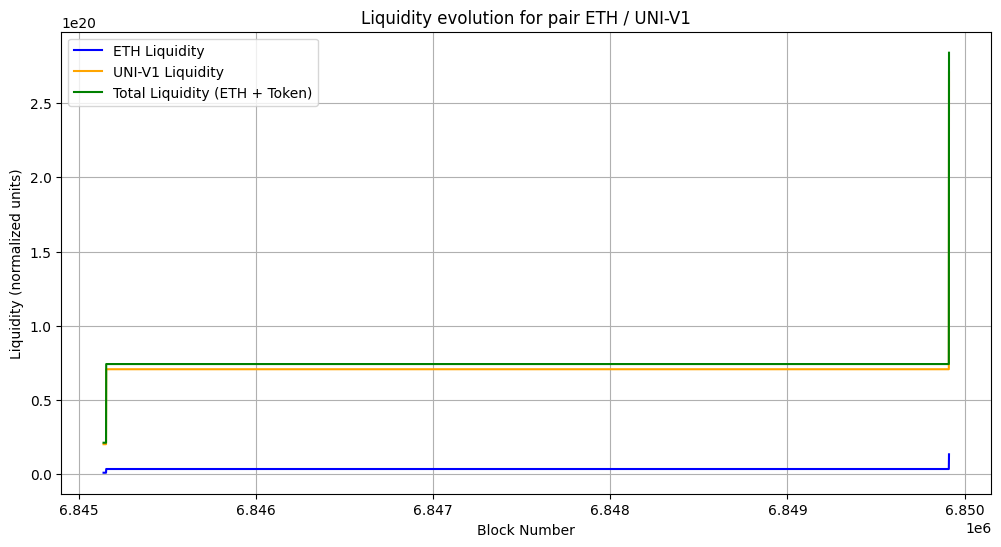

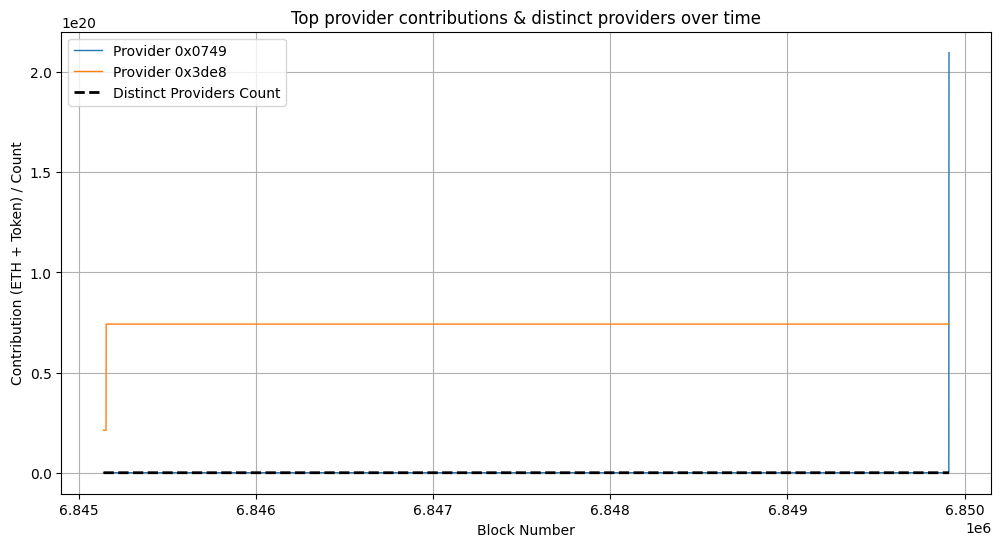

In [4]:
uniswap_v1_factory_address = w3.to_checksum_address(
    "0x255e60c9d597dCAA66006A904eD36424F7B26286"
)
uniswap_v1_factory_abi = get_abi(uniswap_v1_factory_address, ETHERSCAN_API_KEY)
uniswap_v1_factory_contract = w3.eth.contract(
    address=uniswap_v1_factory_address, abi=uniswap_v1_factory_abi
)
exchange_contract = uniswap_v1_factory_contract

def fetch_liquidity_events(exchange_contract, start_block: int, end_block: int):
    """
    Fetches AddLiquidity & RemoveLiquidity events from the Uniswap V1 exchange contract
    between start_block and end_block inclusive.
    Returns a list of dicts with raw event args plus block number, tx hash.
    """
    add_logs = exchange_contract.events.AddLiquidity().get_logs(
        from_block=start_block, to_block=end_block
    )
    remove_logs = exchange_contract.events.RemoveLiquidity().get_logs(
        from_block=start_block, to_block=end_block
    )
    events = []
    for ev in add_logs:
        ev_args = ev["args"]
        events.append(
            {
                "type": "add",
                "block": ev["blockNumber"],
                "tx_hash": (
                    ev["transactionHash"].hex()
                    if hasattr(ev["transactionHash"], "hex")
                    else ev["transactionHash"]
                ),
                "provider": (
                    ev_args["provider"].lower() if "provider" in ev_args else None
                ),
                "eth_amount": Decimal(ev_args.get("eth_amount", 0)),
                "token_amount": Decimal(ev_args.get("token_amount", 0)),
            }
        )
    for ev in remove_logs:
        ev_args = ev["args"]
        events.append(
            {
                "type": "remove",
                "block": ev["blockNumber"],
                "tx_hash": (
                    ev["transactionHash"].hex()
                    if hasattr(ev["transactionHash"], "hex")
                    else ev["transactionHash"]
                ),
                "provider": (
                    ev_args["provider"].lower() if "provider" in ev_args else None
                ),
                "eth_amount": Decimal(ev_args.get("eth_amount", 0)),
                "token_amount": Decimal(ev_args.get("token_amount", 0)),
            }
        )
    # Optionally sort by block then by type or tx_hash
    events.sort(key=lambda e: (e["block"], e["type"]))
    return events


def fetch_reserves(exchange_contract, block_identifier):
    """
    Fetches current ETH and token reserves for the exchange contract at particular block.
    Returns a tuple (eth_reserve: Decimal, token_reserve: Decimal).
    """
    # ETH reserve = balance of the contract
    balance_eth = w3.eth.get_balance(
        exchange_contract.address, block_identifier=block_identifier
    )
    # Token reserve: the token contract, call balanceOf(exchange_contract) at that block
    # Need token address from the exchange:
    token_address = exchange_contract.functions.tokenAddress().call()
    token_abi = get_abi(token_address, ETHERSCAN_API_KEY)
    token_contract = w3.eth.contract(address=token_address, abi=token_abi)
    token_balance = token_contract.functions.balanceOf(exchange_contract.address).call(
        block_identifier=block_identifier
    )
    # Convert to Decimal (and possibly normalize by decimals if needed)
    # Get decimals
    decimals = token_contract.functions.decimals().call()
    eth_res = Decimal(balance_eth) / (10**18)
    token_res = Decimal(token_balance) / (10**decimals)
    return eth_res, token_res


def normalize_events_with_reserves(events_raw, exchange_contract):
    """
    Given raw add/remove events, produce normalized events with both ETH and token amounts.
    If token_amount is zero (or partial), attempt to infer from reserves ratio:
    token_amount ≈ (eth_amount * token_reserve / eth_reserve) (for adds)
    or similarly for removes using LP token share if retrievable.
    Returns list of normalized dicts, each has:
      - block
      - provider
      - type ('add' or 'remove')
      - eth_amount (Decimal)
      - token_amount (Decimal)
      - tx_hash
    """
    normalized = []
    for ev in events_raw:
        eth_amt = ev["eth_amount"]
        token_amt = ev["token_amount"]
        block = ev["block"]
        typ = ev["type"]
        provider = ev.get("provider")
        tx = ev.get("tx_hash")

        if token_amt == 0 or eth_amt == 0:
            # try to infer missing side
            eth_res, token_res = fetch_reserves(
                exchange_contract, block - 1
            )  # before this event
            if eth_res == 0 or token_res == 0:
                # cannot infer properly; skip or set token_amt = 0
                inferred_token_amt = Decimal(0)
            else:
                inferred_token_amt = (eth_amt * token_res) / eth_res
            token_amt = inferred_token_amt

        normalized.append(
            {
                "block": block,
                "provider": provider,
                "type": typ,
                "eth_amount": eth_amt,
                "token_amount": token_amt,
                "tx_hash": tx,
            }
        )

    return normalized


def analyze_transaction_transfers(tx_hash, pair_exchange_contract, etherscan_api_key):
    """
    Improved version of your function for extracting token transfers during a specific transaction.
    Adds better structure and caching where possible.
    """
    result = []
    # get transaction
    tx = w3.eth.get_transaction(tx_hash)
    receipt = w3.eth.get_transaction_receipt(tx_hash)
    eth_value_wei = tx["value"]
    tx_eth_value = w3.from_wei(eth_value_wei, "ether")

    # Decode Transfer events
    decoded = pair_exchange_contract.events.Transfer().process_receipt(receipt, DISCARD)

    for ev in decoded:
        args = ev["args"]
        d_from = args.get("_from")
        d_to = args.get("_to")
        raw_value = args.get("_value")
        d_block = ev["blockNumber"]
        d_tx_hash = (
            ev["transactionHash"].hex()
            if hasattr(ev["transactionHash"], "hex")
            else ev["transactionHash"]
        )
        d_address = ev["address"]
        # resolve token metadata
        token_address = Web3.to_checksum_address(d_address)
        token_abi = get_abi(token_address, etherscan_api_key)
        token_contract = w3.eth.contract(address=token_address, abi=token_abi)
        try:
            symbol = token_contract.functions.symbol().call()
        except Exception:
            symbol = None
        try:
            decimals = token_contract.functions.decimals().call()
        except Exception:
            decimals = 18

        # convert token value
        value_token = Decimal(raw_value) / (10**decimals)

        result.append(
            {
                "block": d_block,
                "from": d_from,
                "to": d_to,
                "value": value_token,
                "token_address": token_address,
                "symbol": symbol,
                "decimals": decimals,
                "tx_eth_value": tx_eth_value,
                "tx_hash": d_tx_hash,
            }
        )

    return result


def fetch_add_remove_logs(exchange_contract, start_block: int, end_block: int):
    """
    Fetch AddLiquidity and RemoveLiquidity logs for the given exchange contract
    between start_block..end_block inclusive.
    Returns a list of raw event dicts.
    """
    # You might need to specify the events in your ABI
    add_logs = exchange_contract.events.AddLiquidity().get_logs(
        from_block=start_block, to_block=end_block
    )
    remove_logs = exchange_contract.events.RemoveLiquidity().get_logs(
        from_block=start_block, to_block=end_block
    )

    raw = []
    for ev in add_logs:
        args = ev["args"]
        raw.append(
            {
                "type": "add",
                "block": ev["blockNumber"],
                "provider": args.get("provider", None),
                "eth_amount": Decimal(args.get("eth_amount", 0)),
                "token_amount": Decimal(args.get("token_amount", 0)),
                "tx_hash": (
                    ev["transactionHash"].hex()
                    if hasattr(ev["transactionHash"], "hex")
                    else ev["transactionHash"]
                ),
            }
        )
    for ev in remove_logs:
        args = ev["args"]
        raw.append(
            {
                "type": "remove",
                "block": ev["blockNumber"],
                "provider": args.get("provider", None),
                "eth_amount": Decimal(args.get("eth_amount", 0)),
                "token_amount": Decimal(args.get("token_amount", 0)),
                "tx_hash": (
                    ev["transactionHash"].hex()
                    if hasattr(ev["transactionHash"], "hex")
                    else ev["transactionHash"]
                ),
            }
        )
    # sort by block
    raw = sorted(raw, key=lambda e: e["block"])
    return raw


def get_reserves(exchange_contract, block_identifier):
    """
    Returns (eth_reserve, token_reserve) at the given block
    Reserves normalized to human-friendly units (i.e. account for decimals).
    """
    # ETH reserve is the contract's ETH balance
    balance_eth_wei = w3.eth.get_balance(
        exchange_contract.address, block_identifier=block_identifier
    )
    # Token reserve: need token contract
    token_address = exchange_contract.functions.tokenAddress().call()
    token_abi = get_abi(token_address, ETHERSCAN_API_KEY)
    token_contract = w3.eth.contract(address=token_address, abi=token_abi)
    token_balance = token_contract.functions.balanceOf(exchange_contract.address).call(
        block_identifier=block_identifier
    )
    token_decimals = token_contract.functions.decimals().call()

    eth_reserve = Decimal(balance_eth_wei) / (10**18)
    token_reserve = Decimal(token_balance) / (10**token_decimals)

    return eth_reserve, token_reserve


def normalize_events_with_inference(raw_events, exchange_contract):
    """
    Takes raw add/remove events and ensures both eth_amount and token_amount are populated.
    If token_amount is zero but eth_amount present (or vice versa), infer using reserves ratios.
    Returns normalized list of events.
    """
    normalized = []
    for ev in raw_events:
        block = ev["block"]
        typ = ev["type"]
        provider = ev["provider"].lower() if ev.get("provider") else None
        eth_amt = ev["eth_amount"]
        token_amt = ev["token_amount"]

        # If one side zero or missing, try inference
        if eth_amt == 0 or token_amt == 0:
            # Fetch reserves just before this event block if possible
            # Try block −1 or block
            # Be careful if block==0
            blk_for_reserves = block - 1 if block > 0 else block
            eth_res, token_res = get_reserves(exchange_contract, blk_for_reserves)
            if eth_res == 0 or token_res == 0:
                # cannot infer
                inferred_token = token_amt if token_amt != 0 else Decimal(0)
            else:
                # If eth_amt present, infer token via ratio; else if token_amt present, infer eth similarly
                if eth_amt != 0 and token_amt == 0:
                    inferred_token = eth_amt * token_res / eth_res
                elif token_amt != 0 and eth_amt == 0:
                    inferred_eth = token_amt * eth_res / token_res
                    eth_amt = inferred_eth
                    inferred_token = token_amt
                else:
                    inferred_token = token_amt
            token_amt = inferred_token

        normalized.append(
            {
                "block": block,
                "provider": provider,
                "type": typ,
                "eth_amount": eth_amt,
                "token_amount": token_amt,
                "tx_hash": ev["tx_hash"],
            }
        )
    return normalized


def build_tvl_and_provider_series(norm_events, epsilon: Decimal = Decimal("1e-8")):
    """
    From normalized events, build:
      - DataFrame of cumulative ETH, token, total liquidity per block (forward-filled)
      - DataFrame of distinct providers count per block
      - Provider contribution time series
    """
    # DataFrame
    df = pd.DataFrame(norm_events)
    df["block"] = df["block"].astype(int)
    df = df.sort_values("block").reset_index(drop=True)

    min_block = df["block"].min()
    max_block = df["block"].max()

    blocks = list(range(min_block, max_block + 1))
    cum_eth = []
    cum_token = []
    distinct_counts = []

    providers_net = defaultdict(lambda: {"eth": Decimal("0"), "token": Decimal("0")})
    provider_timeseries = {
        prov: [] for prov in set(ev["provider"] for ev in norm_events if ev["provider"])
    }

    current_eth = Decimal("0")
    current_token = Decimal("0")

    grouped = df.groupby("block")

    for blk in blocks:
        if blk in grouped.groups:
            for _, ev in grouped.get_group(blk).iterrows():
                prov = ev["provider"]
                typ = ev["type"]
                if typ == "add":
                    current_eth += ev["eth_amount"]
                    current_token += ev["token_amount"]
                    if prov:
                        providers_net[prov]["eth"] += ev["eth_amount"]
                        providers_net[prov]["token"] += ev["token_amount"]
                elif typ == "remove":
                    current_eth -= ev["eth_amount"]
                    current_token -= ev["token_amount"]
                    if prov:
                        providers_net[prov]["eth"] -= ev["eth_amount"]
                        providers_net[prov]["token"] -= ev["token_amount"]
                else:
                    # skip
                    pass

        # At this block, record cumulative
        cum_eth.append(current_eth)
        cum_token.append(current_token)

        # count distinct providers with net outstanding > epsilon
        cnt = sum(
            1 for prov, v in providers_net.items() if (v["eth"] + v["token"]) > epsilon
        )
        distinct_counts.append(cnt)

        # update per‐provider timeseries
        for prov in provider_timeseries:
            v = providers_net.get(prov, {"eth": Decimal("0"), "token": Decimal("0")})
            provider_timeseries[prov].append(v["eth"] + v["token"])

    df_tvl = pd.DataFrame({"block": blocks, "cum_eth": cum_eth, "cum_token": cum_token})
    df_tvl["cum_total"] = df_tvl["cum_eth"] + df_tvl["cum_token"]

    df_providers = pd.DataFrame(
        {"block": blocks, "distinct_providers": distinct_counts}
    )

    return df_tvl, df_providers, provider_timeseries


def plot_liquidity_pair(df_tvl, token_symbol: str = "TOKEN"):
    plt.figure(figsize=(12, 6))
    plt.plot(df_tvl["block"], df_tvl["cum_eth"], label="ETH Liquidity", color="blue")
    plt.plot(
        df_tvl["block"],
        df_tvl["cum_token"],
        label=f"{token_symbol} Liquidity",
        color="orange",
    )
    plt.plot(
        df_tvl["block"],
        df_tvl["cum_total"],
        label="Total Liquidity (ETH + Token)",
        color="green",
    )
    plt.xlabel("Block Number")
    plt.ylabel("Liquidity (normalized units)")
    plt.title(f"Liquidity evolution for pair ETH / {token_symbol}")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_provider_contributions(df_providers, provider_ts, top_n: int = 5):
    """
    Plot contributions of top_n providers, plus total distinct provider counts.
    """
    plt.figure(figsize=(12, 6))
    # identify top_n providers by last value
    last_vals = {prov: series[-1] for prov, series in provider_ts.items()}
    # filter providers with non-zero
    filtered = {prov: val for prov, val in last_vals.items() if val != 0}
    top = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_providers = [prov for prov, _ in top]

    # Plot each
    for prov in top_providers:
        plt.plot(
            df_providers["block"],
            provider_ts[prov],
            label=f"Provider {prov[:6]}",
            linewidth=1,
        )

    # Plot distinct count
    plt.plot(
        df_providers["block"],
        df_providers["distinct_providers"],
        label="Distinct Providers Count",
        color="black",
        linestyle="--",
        linewidth=2,
    )

    plt.xlabel("Block Number")
    plt.ylabel("Contribution (ETH + Token) / Count")
    plt.title("Top provider contributions & distinct providers over time")
    plt.legend()
    plt.grid(True)
    plt.show()


def main(start_block: int, end_block: int, token_symbol: str = "TOKEN"):
    """
    Main routine: fetch events, normalize, build series, plot.
    """
    # 1. Fetch raw add/remove logs
    raw = fetch_add_remove_logs(exchange_contract, start_block, end_block)

    # 2. Normalize (fill missing sides)
    norm = normalize_events_with_inference(raw, exchange_contract)

    # 3. Build TVL & provider series
    df_tvl, df_providers, provider_ts = build_tvl_and_provider_series(norm)

    # 4. Plot pair liquidity
    plot_liquidity_pair(df_tvl, token_symbol=token_symbol)

    # 5. Plot providers contributions
    plot_provider_contributions(df_providers, provider_ts, top_n=5)

    # Optionally return dataframes for further analysis
    return df_tvl, df_providers, provider_ts


if __name__ == "__main__":
    df_tvl, df_providers, provider_ts = main(
        start_block=6800000, 
        # end_block=6850000, 
        end_block=10000000,
        token_symbol="UNI-V1"
    )

In [9]:
# Assume the following exist in your environment:
#   w3
#   exchange_contract  # the Uniswap V1 pair / exchange contract for ETH/token
#   get_abi(token_address, API_KEY)
#   ETHERSCAN_API_KEY
#   start_block (int), end_block (int)
#   token_symbol (str)  # e.g. "UNI-V1", or whatever your token is


def fetch_add_remove_logs(exchange_contract, start_block: int, end_block: int):
    """Fetch Uniswap V1 AddLiquidity and RemoveLiquidity events between start_block and end_block."""
    add_logs = exchange_contract.events.AddLiquidity().get_logs(
        from_block=start_block, to_block=end_block
    )
    remove_logs = exchange_contract.events.RemoveLiquidity().get_logs(
        from_block=start_block, to_block=end_block
    )
    raw_events = []
    for ev in add_logs:
        args = ev["args"]
        raw_events.append(
            {
                "type": "add",
                "block": ev["blockNumber"],
                "provider": args.get("provider", None),
                "eth_amount": args.get("eth_amount", 0),
                "token_amount": args.get("token_amount", 0),
                "tx_hash": (
                    ev["transactionHash"].hex()
                    if hasattr(ev["transactionHash"], "hex")
                    else ev["transactionHash"]
                ),
            }
        )
    for ev in remove_logs:
        args = ev["args"]
        raw_events.append(
            {
                "type": "remove",
                "block": ev["blockNumber"],
                "provider": args.get("provider", None),
                "eth_amount": args.get("eth_amount", 0),
                "token_amount": args.get("token_amount", 0),
                "tx_hash": (
                    ev["transactionHash"].hex()
                    if hasattr(ev["transactionHash"], "hex")
                    else ev["transactionHash"]
                ),
            }
        )
    # sort by block asc
    raw_events.sort(key=lambda e: e["block"])
    return raw_events


def get_reserves(exchange_contract, block_identifier: int):
    """Get normalized reserves (ETH, token) at a given block identifier."""
    # ETH side
    balance_eth_wei = w3.eth.get_balance(
        exchange_contract.address, block_identifier=block_identifier
    )
    # Token side
    token_addr = exchange_contract.functions.tokenAddress().call(
        block_identifier=block_identifier
    )
    token_abi = get_abi(token_addr, ETHERSCAN_API_KEY)
    token_contract = w3.eth.contract(address=token_addr, abi=token_abi)
    token_balance = token_contract.functions.balanceOf(exchange_contract.address).call(
        block_identifier=block_identifier
    )
    token_decimals = token_contract.functions.decimals().call(
        block_identifier=block_identifier
    )
    eth_reserve = Decimal(balance_eth_wei) / (10**18)
    token_reserve = Decimal(token_balance) / (10**token_decimals)
    return eth_reserve, token_reserve


def normalize_events_with_inference(raw_events):
    """Normalize raw events: ensure eth_amount + token_amount both populated, inferring if needed."""
    normalized = []
    for ev in raw_events:
        block = ev["block"]
        typ = ev["type"]
        prov = ev.get("provider")
        eth_amt = Decimal(ev["eth_amount"])
        token_amt = Decimal(ev["token_amount"])
        txh = ev["tx_hash"]

        if eth_amt == 0 or token_amt == 0:
            # try to infer from reserves just before event block
            blk_for_res = block - 1 if block > 0 else block
            eth_res, token_res = get_reserves(exchange_contract, blk_for_res)
            if eth_res > 0 and token_res > 0:
                if eth_amt != 0 and token_amt == 0:
                    token_amt = eth_amt * token_res / eth_res
                elif token_amt != 0 and eth_amt == 0:
                    eth_amt = token_amt * eth_res / token_res
                # else if both zero or both non-zero, leave as is

        normalized.append(
            {
                "block": block,
                "provider": prov.lower() if prov else None,
                "type": typ,  # 'add' or 'remove'
                "eth_amount": eth_amt,
                "token_amount": token_amt,
                "tx_hash": txh,
            }
        )
    return normalized


def build_time_series(norm_events, end_block, epsilon: Decimal = Decimal("1e-8")):
    """
    Build TVL and provider series from normalized events across block range.
    Returns:
      - df_tvl: DataFrame with block, cum_eth, cum_token, cum_total
      - df_providers: DataFrame with block, distinct_providers
      - provider_timeseries: dict(provider_address -> list of net contribution over blocks)
    """
    df = pd.DataFrame(norm_events)
    df["block"] = df["block"].astype(int)
    df = df.sort_values("block").reset_index(drop=True)

    min_block = df["block"].min()
    max_block = max(
        end_block, df["block"].max()
    )  # ensure covers the requested end_block

    blocks = list(range(min_block, max_block + 1))
    cum_eth = []
    cum_token = []
    distinct_counts = []

    providers_net = defaultdict(lambda: {"eth": Decimal("0"), "token": Decimal("0")})
    provider_ts = {
        prov: []
        for prov in set(ev["provider"] for ev in norm_events if ev.get("provider"))
    }

    curr_eth = Decimal("0")
    curr_token = Decimal("0")

    grouped = df.groupby("block")

    for blk in blocks:
        if blk in grouped.groups:
            for _, ev in grouped.get_group(blk).iterrows():
                prov = ev.get("provider")
                typ = ev["type"]
                if typ == "add":
                    curr_eth += ev["eth_amount"]
                    curr_token += ev["token_amount"]
                    if prov:
                        providers_net[prov]["eth"] += ev["eth_amount"]
                        providers_net[prov]["token"] += ev["token_amount"]
                elif typ == "remove":
                    curr_eth -= ev["eth_amount"]
                    curr_token -= ev["token_amount"]
                    if prov:
                        providers_net[prov]["eth"] -= ev["eth_amount"]
                        providers_net[prov]["token"] -= ev["token_amount"]
        # record at this block
        cum_eth.append(curr_eth)
        cum_token.append(curr_token)

        # count distinct providers whose net (eth + token) > epsilon
        cnt = sum(
            1 for prov, v in providers_net.items() if (v["eth"] + v["token"]) > epsilon
        )
        distinct_counts.append(cnt)

        # update providers’ individual time series
        for prov in provider_ts:
            net = providers_net.get(prov, {"eth": Decimal("0"), "token": Decimal("0")})
            provider_ts[prov].append(net["eth"] + net["token"])

    df_tvl = pd.DataFrame({"block": blocks, "cum_eth": cum_eth, "cum_token": cum_token})
    df_tvl["cum_total"] = df_tvl["cum_eth"] + df_tvl["cum_token"]

    df_providers = pd.DataFrame(
        {"block": blocks, "distinct_providers": distinct_counts}
    )

    return df_tvl, df_providers, provider_ts


def plot_pair_liquidity_plotly(df_tvl, token_symbol: str = "TOKEN"):
    """Interactive chart: ETH, token, total liquidity over blocks."""
    df_plot = df_tvl.copy()
    df_plot["block"] = df_plot["block"].astype(int)

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=df_plot["block"],
            y=[float(val) for val in df_plot["cum_eth"]],
            mode="lines",
            name="ETH Liquidity",
            hovertemplate="Block %{x}<br>ETH: %{y:.6f}<extra></extra>",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=df_plot["block"],
            y=[float(val) for val in df_plot["cum_token"]],
            mode="lines",
            name=f"{token_symbol} Liquidity",
            hovertemplate="Block %{x}<br>" + f"{token_symbol}: %{y:.6f}<extra></extra>",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=df_plot["block"],
            y=[float(val) for val in df_plot["cum_total"]],
            mode="lines",
            name="Total (ETH + Token)",
            line=dict(dash="dot"),
            hovertemplate="Block %{x}<br>Total: %{y:.6f}<extra></extra>",
        )
    )

    fig.update_layout(
        title=f"Liquidity evolution ETH / {token_symbol}",
        xaxis=dict(
            title="Block Number", tickformat="d", type="linear"  # integer formatting
        ),
        yaxis=dict(title="Liquidity (normalized units)"),
        hovermode="x unified",
    )

    fig.show()


def plot_provider_contributions_plotly(df_providers, provider_ts, top_n: int = 5):
    """Interactive chart: top provider contributions + distinct provider count."""
    blocks = [int(b) for b in df_providers["block"]]

    # determine top_n providers
    last_vals = {prov: provider_ts[prov][-1] for prov in provider_ts}
    filtered = {prov: val for prov, val in last_vals.items() if float(val) != 0.0}
    top = sorted(filtered.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]
    top_provs = [prov for prov, _ in top]

    fig = go.Figure()
    for prov in top_provs:
        series = [float(v) for v in provider_ts[prov]]
        fig.add_trace(
            go.Scatter(
                x=blocks,
                y=series,
                mode="lines",
                name=f"Provider {prov[:8]}",
                hovertemplate="Block %{x}<br>"
                + f"{prov[:8]}: "
                + "%{y:.6f}<extra></extra>",
            )
        )

    # distinct provider count
    fig.add_trace(
        go.Scatter(
            x=blocks,
            y=[int(v) for v in df_providers["distinct_providers"]],
            mode="lines+markers",
            name="Distinct Providers Count",
            line=dict(color="black", dash="dash"),
            hovertemplate="Block %{x}<br>Distinct Providers: %{y:d}<extra></extra>",
        )
    )

    fig.update_layout(
        title="Provider Contributions & Distinct Providers Over Time",
        xaxis=dict(title="Block Number", tickformat="d", type="linear"),
        yaxis=dict(title="Contribution & Count"),
        hovermode="x unified",
    )

    fig.show()


def main(start_block: int, end_block: int, token_symbol: str = "TOKEN"):
    raw = fetch_add_remove_logs(exchange_contract, start_block, end_block)
    norm = normalize_events_with_inference(raw)
    df_tvl, df_providers, provider_ts = build_time_series(norm, end_block)
    plot_pair_liquidity_plotly(df_tvl, token_symbol=token_symbol)
    plot_provider_contributions_plotly(df_providers, provider_ts, top_n=5)
    return df_tvl, df_providers, provider_ts


# Example usage:
df_tvl, df_providers, provider_ts = main(start_block=6800000, end_block=10000000, token_symbol="UNI-V1")

NameError: name 'y' is not defined

In [ ]:
import plotly.graph_objects as go
import pandas as pd
from collections import defaultdict
from decimal import Decimal


def plot_pair_liquidity_plotly(df_tvl, token_symbol="TOKEN"):
    """Interactive chart: ETH, token, total liquidity over blocks."""
    df_plot = df_tvl.copy()
    df_plot["block"] = df_plot["block"].astype(int)

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=df_plot["block"],
            y=[float(val) for val in df_plot["cum_eth"]],
            mode="lines",
            name="ETH Liquidity",
            hovertemplate="Block %{x}<br>ETH: %{y:.6f}<extra></extra>",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=df_plot["block"],
            y=[float(val) for val in df_plot["cum_token"]],
            mode="lines",
            name=f"{token_symbol} Liquidity",
            hovertemplate="Block %{x}<br>" + f"{token_symbol}: %{y:.6f}<extra></extra>",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=df_plot["block"],
            y=[float(val) for val in df_plot["cum_total"]],
            mode="lines",
            name="Total (ETH + Token)",
            line=dict(dash="dot"),
            hovertemplate="Block %{x}<br>Total: %{y:.6f}<extra></extra>",
        )
    )

    fig.update_layout(
        title=f"Liquidity evolution ETH / {token_symbol}",
        xaxis=dict(
            title="Block Number",
            tickformat="d",  # integer formatting
            type="linear",
            showexponent="all",  # Show exponent notation if needed
            exponentformat="none",  # Avoid scientific notation
        ),
        yaxis=dict(
            title="Liquidity (normalized units)",
            tickformat=".6f",  # Format Y-axis values to 6 decimal places
        ),
        hovermode="x unified",
    )

    fig.show()


def plot_provider_contributions_plotly(df_providers, provider_ts, top_n=5):
    """Interactive chart: top provider contributions + distinct provider count."""
    blocks = [int(b) for b in df_providers["block"]]

    # Determine top_n providers
    last_vals = {prov: provider_ts[prov][-1] for prov in provider_ts}
    filtered = {prov: val for prov, val in last_vals.items() if float(val) != 0.0}
    top = sorted(filtered.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]
    top_provs = [prov for prov, _ in top]

    fig = go.Figure()
    for prov in top_provs:
        series = [float(v) for v in provider_ts[prov]]
        fig.add_trace(
            go.Scatter(
                x=blocks,
                y=series,
                mode="lines",
                name=f"Provider {prov[:8]}",
                hovertemplate="Block %{x}<br>"
                + f"{prov[:8]}: "
                + "%{y:.6f}<extra></extra>",
            )
        )

    # Distinct provider count
    fig.add_trace(
        go.Scatter(
            x=blocks,
            y=[int(v) for v in df_providers["distinct_providers"]],
            mode="lines+markers",
            name="Distinct Providers Count",
            line=dict(color="black", dash="dash"),
            hovertemplate="Block %{x}<br>Distinct Providers: %{y:d}<extra></extra>",
        )
    )

    fig.update_layout(
        title="Provider Contributions & Distinct Providers Over Time",
        xaxis=dict(
            title="Block Number",
            tickformat="d",  # integer formatting
            type="linear",
            showexponent="all",  # Show exponent notation if needed
            exponentformat="none",  # Avoid scientific notation
        ),
        yaxis=dict(
            title="Contribution & Count",
            tickformat=".6f",  # Format Y-axis values to 6 decimal places
        ),
        hovermode="x unified",
    )

    fig.show()


# Example usage:
# Assuming df_tvl, df_providers, and provider_ts are already defined
# plot_pair_liquidity_plotly(df_tvl, token_symbol="UNI-V1")
# plot_provider_contributions_plotly(df_providers, provider_ts, top_n=5)

NameError: name 'y' is not defined